# CHEC project 

In [1]:
print("hi from COLAB (GPUT T4 env)")

hi from COLAB (GPUT T4 env)


## environment libs

In [2]:
# -----------------------------------------------------------
# Configuración general del entorno: warnings, librerías y estilo gráfico
# -----------------------------------------------------------
# %pip install --quiet kagglehub[pandas-datasets] pandas numpy matplotlib seaborn plotly scikit-learn tensorflow

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from pathlib import Path
from typing import List, Sequence

import numpy as np
import pandas as pd

import kagglehub
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.preprocessing import LabelEncoder
try:
    import tensorflow as tf
except ImportError:
    tf = None
    print('TensorFlow no está instalado; instala tensorflow si deseas ejecutar la parte DL.')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)


## data import 

In [3]:
import kagglehub
import pandas as pd
from pathlib import Path

dataset_dir = Path(kagglehub.dataset_download("cristiancamiloo/powergrid-assets-ml-dataset"))
file_path = dataset_dir / "Dataset_Full_Enriched.pkl"

df = pd.read_pickle(file_path)  # ajusta encoding/compression si hiciera falta



100%|██████████| 65.8M/65.8M [00:04<00:00, 17.1MB/s]

Extracting files...


display basic info

In [4]:
print("First 5 rows:")
display(df.head())


First 5 rows:


,CODIGO,TIPO,FECHA,DURACION,UITI,COD_CAUSA,NFASES,NEUTRO,LONGITUD,CALIBRE_F,...,clouds_15,clouds_16,clouds_17,clouds_18,clouds_19,clouds_20,clouds_21,clouds_22,clouds_23,clouds_24
0,28648,3RG,11/08/2024 20:45,0.18,398.00,22,3,1,57.62,1/0,...,100.0,100.0,100.0,100.0,98.0,100.0,100.0,100.0,100.0,100.0
1,28648,3RG,18/11/2024 14:43,0.10,120.75,12,3,1,57.62,1/0,...,100.0,100.0,100.0,99.0,99.0,94.0,87.0,58.0,41.0,88.0
2,28648,3RG,18/11/2024 14:43,0.77,812.06,12,3,1,57.62,1/0,...,100.0,100.0,100.0,99.0,99.0,94.0,87.0,58.0,41.0,88.0
3,28648,3RG,18/11/2024 15:27,0.03,37.58,12,3,1,57.62,1/0,...,100.0,100.0,100.0,100.0,99.0,99.0,94.0,87.0,58.0,41.0
4,28648,3RG,18/11/2024 15:30,0.06,150.36,12,3,1,57.62,1/0,...,100.0,100.0,100.0,100.0,99.0,99.0,94.0,87.0,58.0,41.0


select target : 

In [5]:
TARGET_COL = "UITI"
print(f"Dataset con {df.shape[0]:,} filas y {df.shape[1]:,} columnas")


Dataset con 661,811 filas y 275 columnas


create a copy of the db

In [6]:
df_original = df.copy()


## EDA 


first, a basic quantitiative metrics of the original dataset 

In [8]:
overview = pd.DataFrame(
    {
        'metricas': ['total_filas', 'total_columnas', 'duplicados', 'memoria_MB'],
        'valor': [
            int(len(df)),
            int(df.shape[1]),
            int(df.duplicated().sum()),
            round(df.memory_usage(deep=True).sum() / (1024 ** 2), 2),
        ],
    }
)
# display 
display(overview)

,metricas,valor
0,total_filas,661811.00
1,total_columnas,275.00
2,duplicados,4922.00
3,memoria_MB,1713.61


also a structural report: 

In [9]:
structure_report = pd.DataFrame(
    {
        'columna': df.columns,
        'tipo_python': df.dtypes.astype(str).values,
        'nulos': df.isna().sum().values,
        'pct_nulos': (df.isna().sum().values / len(df)),
        'cardinalidad': df.nunique(dropna=False).values,
    }
).sort_values(by='pct_nulos', ascending=False)
# display 
display(structure_report)


,columna,tipo_python,nulos,pct_nulos,cardinalidad
195,vis_20,float64,661811,1.0,1
196,vis_21,float64,661811,1.0,1
197,vis_22,float64,661811,1.0,1
198,vis_23,float64,661811,1.0,1
199,vis_24,float64,661811,1.0,1
...,...,...,...,...,...
263,clouds_13,float64,0,0.0,101
262,clouds_12,float64,0,0.0,101
5,COD_CAUSA,int64,0,0.0,37
4,UITI,float64,0,0.0,13629


muestreo rapido para vaidar consistencia antes de la EDA? 

In [10]:
with pd.option_context('display.max_columns', None):
    display(df.head(3))
    display(df.tail(3))
    display(df.sample(min(5, len(df)), random_state=42))

,CODIGO,TIPO,FECHA,DURACION,UITI,COD_CAUSA,NFASES,NEUTRO,LONGITUD,CALIBRE_F,MATERIAL_F,AISLAMIENTO_F,G_N,CALIBRE_NEUTRO,X2,Y2,FECHA_OPERACION,TIPO_TAXONOMIA,CLASE,ALTURA,CANTIDAD_TIERRA,LONG_CRUCETA,TRAFO,VEGETACION,ENERG_CIRCULA,prep_0,prep_1,prep_2,prep_3,prep_4,prep_5,prep_6,prep_7,prep_8,prep_9,prep_10,prep_11,prep_12,prep_13,prep_14,prep_15,prep_16,prep_17,prep_18,prep_19,prep_20,prep_21,prep_22,prep_23,prep_24,pres_0,pres_1,pres_2,pres_3,pres_4,pres_5,pres_6,pres_7,pres_8,pres_9,pres_10,pres_11,pres_12,pres_13,pres_14,pres_15,pres_16,pres_17,pres_18,pres_19,pres_20,pres_21,pres_22,pres_23,pres_24,sp_0,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,sp_8,sp_9,sp_10,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20,sp_21,sp_22,sp_23,sp_24,rh_0,rh_1,rh_2,rh_3,rh_4,rh_5,rh_6,rh_7,rh_8,rh_9,rh_10,rh_11,rh_12,rh_13,rh_14,rh_15,rh_16,rh_17,rh_18,rh_19,rh_20,rh_21,rh_22,rh_23,rh_24,solar_rad_0,solar_rad_1,solar_rad_2,solar_rad_3,solar_rad_4,solar_rad_5,solar_rad_6,solar_rad_7,solar_rad_8,solar_rad_9,solar_rad_10,solar_rad_11,solar_rad_12,solar_rad_13,solar_rad_14,solar_rad_15,solar_rad_16,solar_rad_17,solar_rad_18,solar_rad_19,solar_rad_20,solar_rad_21,solar_rad_22,solar_rad_23,solar_rad_24,temp_0,temp_1,temp_2,temp_3,temp_4,temp_5,temp_6,temp_7,temp_8,temp_9,temp_10,temp_11,temp_12,temp_13,temp_14,temp_15,temp_16,temp_17,temp_18,temp_19,temp_20,temp_21,temp_22,temp_23,temp_24,vis_0,vis_1,vis_2,vis_3,vis_4,vis_5,vis_6,vis_7,vis_8,vis_9,vis_10,vis_11,vis_12,vis_13,vis_14,vis_15,vis_16,vis_17,vis_18,vis_19,vis_20,vis_21,vis_22,vis_23,vis_24,wind_gust_spd_0,wind_gust_spd_1,wind_gust_spd_2,wind_gust_spd_3,wind_gust_spd_4,wind_gust_spd_5,wind_gust_spd_6,wind_gust_spd_7,wind_gust_spd_8,wind_gust_spd_9,wind_gust_spd_10,wind_gust_spd_11,wind_gust_spd_12,wind_gust_spd_13,wind_gust_spd_14,wind_gust_spd_15,wind_gust_spd_16,wind_gust_spd_17,wind_gust_spd_18,wind_gust_spd_19,wind_gust_spd_20,wind_gust_spd_21,wind_gust_spd_22,wind_gust_spd_23,wind_gust_spd_24,wind_spd_0,wind_spd_1,wind_spd_2,wind_spd_3,wind_spd_4,wind_spd_5,wind_spd_6,wind_spd_7,wind_spd_8,wind_spd_9,wind_spd_10,wind_spd_11,wind_spd_12,wind_spd_13,wind_spd_14,wind_spd_15,wind_spd_16,wind_spd_17,wind_spd_18,wind_spd_19,wind_spd_20,wind_spd_21,wind_spd_22,wind_spd_23,wind_spd_24,clouds_0,clouds_1,clouds_2,clouds_3,clouds_4,clouds_5,clouds_6,clouds_7,clouds_8,clouds_9,clouds_10,clouds_11,clouds_12,clouds_13,clouds_14,clouds_15,clouds_16,clouds_17,clouds_18,clouds_19,clouds_20,clouds_21,clouds_22,clouds_23,clouds_24
0,28648,3RG,11/08/2024 20:45,0.18,398.00,22,3,1,57.62,1/0,ACSR,DESNUDO,N,2,-75.45,5.6,1995,Troncal_linea,T,12.0,1,2.0,0,0,13212.66,0.0,0.0,0.0,0.0,2.7,4.0,4.7,0.3,0.3,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,2.1,2.1,0.7,1018.900024,1017.599976,1016.599976,1015.599976,1015.400024,1014.700012,1015.700012,1016.200012,1017.400024,1017.900024,1019.000000,1020.099976,1020.200012,1019.400024,1019.500000,1019.000000,1018.799988,1018.700012,1018.900024,1019.299988,1019.500000,1020.099976,1020.099976,1019.599976,1018.299988,791.567078,791.266174,790.622925,790.814087,790.658386,791.566223,792.050537,793.293701,794.132141,794.751587,794.920654,794.451721,793.287903,791.172546,790.702271,790.382996,790.570129,790.595215,790.476746,791.538147,791.897522,792.567261,792.397461,792.110840,791.506897,100.000000,98.410316,98.728424,93.551605,88.035255,78.684731,80.921066,72.991257,72.497284,71.175461,74.025841,83.367691,93.170357,98.062553,99.021034,100.000000,100.000000,100.000000,100.000000,98.711166,100.000000,97.764465,98.714645,92.511848,91.055382,0.0,1.0,106.0,208.0,333.0,617.0,614.0,779.0,741.0,828.0,737.0,535.0,207.0,57.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.5475,15.597500,15.7975,17.247501,17.247501,19.447498,18.997501,20.297501,20.147499,20.497501,19.447498,17.447498,15.5975,13.3975,12.5975,12.6975,13.1975,13.3475,12.9475,14.0475,14.3475,14.647500,14.397500,14.547500,15.147500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

,CODIGO,TIPO,FECHA,DURACION,UITI,COD_CAUSA,NFASES,NEUTRO,LONGITUD,CALIBRE_F,MATERIAL_F,AISLAMIENTO_F,G_N,CALIBRE_NEUTRO,X2,Y2,FECHA_OPERACION,TIPO_TAXONOMIA,CLASE,ALTURA,CANTIDAD_TIERRA,LONG_CRUCETA,TRAFO,VEGETACION,ENERG_CIRCULA,prep_0,prep_1,prep_2,prep_3,prep_4,prep_5,prep_6,prep_7,prep_8,prep_9,prep_10,prep_11,prep_12,prep_13,prep_14,prep_15,prep_16,prep_17,prep_18,prep_19,prep_20,prep_21,prep_22,prep_23,prep_24,pres_0,pres_1,pres_2,pres_3,pres_4,pres_5,pres_6,pres_7,pres_8,pres_9,pres_10,pres_11,pres_12,pres_13,pres_14,pres_15,pres_16,pres_17,pres_18,pres_19,pres_20,pres_21,pres_22,pres_23,pres_24,sp_0,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,sp_8,sp_9,sp_10,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20,sp_21,sp_22,sp_23,sp_24,rh_0,rh_1,rh_2,rh_3,rh_4,rh_5,rh_6,rh_7,rh_8,rh_9,rh_10,rh_11,rh_12,rh_13,rh_14,rh_15,rh_16,rh_17,rh_18,rh_19,rh_20,rh_21,rh_22,rh_23,rh_24,solar_rad_0,solar_rad_1,solar_rad_2,solar_rad_3,solar_rad_4,solar_rad_5,solar_rad_6,solar_rad_7,solar_rad_8,solar_rad_9,solar_rad_10,solar_rad_11,solar_rad_12,solar_rad_13,solar_rad_14,solar_rad_15,solar_rad_16,solar_rad_17,solar_rad_18,solar_rad_19,solar_rad_20,solar_rad_21,solar_rad_22,solar_rad_23,solar_rad_24,temp_0,temp_1,temp_2,temp_3,temp_4,temp_5,temp_6,temp_7,temp_8,temp_9,temp_10,temp_11,temp_12,temp_13,temp_14,temp_15,temp_16,temp_17,temp_18,temp_19,temp_20,temp_21,temp_22,temp_23,temp_24,vis_0,vis_1,vis_2,vis_3,vis_4,vis_5,vis_6,vis_7,vis_8,vis_9,vis_10,vis_11,vis_12,vis_13,vis_14,vis_15,vis_16,vis_17,vis_18,vis_19,vis_20,vis_21,vis_22,vis_23,vis_24,wind_gust_spd_0,wind_gust_spd_1,wind_gust_spd_2,wind_gust_spd_3,wind_gust_spd_4,wind_gust_spd_5,wind_gust_spd_6,wind_gust_spd_7,wind_gust_spd_8,wind_gust_spd_9,wind_gust_spd_10,wind_gust_spd_11,wind_gust_spd_12,wind_gust_spd_13,wind_gust_spd_14,wind_gust_spd_15,wind_gust_spd_16,wind_gust_spd_17,wind_gust_spd_18,wind_gust_spd_19,wind_gust_spd_20,wind_gust_spd_21,wind_gust_spd_22,wind_gust_spd_23,wind_gust_spd_24,wind_spd_0,wind_spd_1,wind_spd_2,wind_spd_3,wind_spd_4,wind_spd_5,wind_spd_6,wind_spd_7,wind_spd_8,wind_spd_9,wind_spd_10,wind_spd_11,wind_spd_12,wind_spd_13,wind_spd_14,wind_spd_15,wind_spd_16,wind_spd_17,wind_spd_18,wind_spd_19,wind_spd_20,wind_spd_21,wind_spd_22,wind_spd_23,wind_spd_24,clouds_0,clouds_1,clouds_2,clouds_3,clouds_4,clouds_5,clouds_6,clouds_7,clouds_8,clouds_9,clouds_10,clouds_11,clouds_12,clouds_13,clouds_14,clouds_15,clouds_16,clouds_17,clouds_18,clouds_19,clouds_20,clouds_21,clouds_22,clouds_23,clouds_24
661808,L0293008,3CFR,02/04/2025 5:12,6.46,1138.13,20,1,1,498.0,2,ACSR,DESNUDO,G,2,-75.51,5.01,2025,Ramal,V,12.0,1,3.0,1,0,0.0,1.0,0.9,0.1,1.7,2.9,2.7,1.3,3.8,0.2,9.3,0.1,4.7,3.0,2.0,9.8,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1014.099976,1013.799988,1013.299988,1013.799988,1014.900024,1015.599976,1015.799988,1015.400024,1014.200012,1014.099976,1012.900024,1012.200012,1010.700012,1010.299988,1010.500000,1009.799988,1011.000000,1012.200012,1013.599976,1014.700012,1015.200012,1015.500000,1015.299988,1014.599976,1013.700012,803.522156,803.412048,803.302490,803.857788,804.698425,805.253418,805.634583,805.761230,804.871887,804.603088,804.218140,803.473755,803.096497,803.182800,803.248779,804.964722,806.285461,806.786377,807.688538,807.981750,807.452087,806.439758,805.460022,803.726135,803.013245,95.834213,94.591805,92.163643,91.276909,92.175369,95.861191,95.250679,94.967987,95.279404,97.137016,90.210770,93.764114,99.051521,92.665947,91.189255,63.022903,60.942883,64.648941,66.704971,72.839561,78.464882,84.833496,75.670853,78.478371,77.166626,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,71.0,218.0,275.0,324.0,721.0,829.0,762.0,839.0,744.0,548.0,290.0,64.0,0.0,0.0,13.090000,13.290000,13.740000,13.990001,13.940000,13.940000,14.290000,14.990001,15.089999,14.79,15.69,15.39,16.689999,17.34,17.189999,20.889999,21.490002,20.740002,20.389999,19.439999,17.939999,15.940000,14.640000,12.79,12.790000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

,CODIGO,TIPO,FECHA,DURACION,UITI,COD_CAUSA,NFASES,NEUTRO,LONGITUD,CALIBRE_F,MATERIAL_F,AISLAMIENTO_F,G_N,CALIBRE_NEUTRO,X2,Y2,FECHA_OPERACION,TIPO_TAXONOMIA,CLASE,ALTURA,CANTIDAD_TIERRA,LONG_CRUCETA,TRAFO,VEGETACION,ENERG_CIRCULA,prep_0,prep_1,prep_2,prep_3,prep_4,prep_5,prep_6,prep_7,prep_8,prep_9,prep_10,prep_11,prep_12,prep_13,prep_14,prep_15,prep_16,prep_17,prep_18,prep_19,prep_20,prep_21,prep_22,prep_23,prep_24,pres_0,pres_1,pres_2,pres_3,pres_4,pres_5,pres_6,pres_7,pres_8,pres_9,pres_10,pres_11,pres_12,pres_13,pres_14,pres_15,pres_16,pres_17,pres_18,pres_19,pres_20,pres_21,pres_22,pres_23,pres_24,sp_0,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,sp_8,sp_9,sp_10,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20,sp_21,sp_22,sp_23,sp_24,rh_0,rh_1,rh_2,rh_3,rh_4,rh_5,rh_6,rh_7,rh_8,rh_9,rh_10,rh_11,rh_12,rh_13,rh_14,rh_15,rh_16,rh_17,rh_18,rh_19,rh_20,rh_21,rh_22,rh_23,rh_24,solar_rad_0,solar_rad_1,solar_rad_2,solar_rad_3,solar_rad_4,solar_rad_5,solar_rad_6,solar_rad_7,solar_rad_8,solar_rad_9,solar_rad_10,solar_rad_11,solar_rad_12,solar_rad_13,solar_rad_14,solar_rad_15,solar_rad_16,solar_rad_17,solar_rad_18,solar_rad_19,solar_rad_20,solar_rad_21,solar_rad_22,solar_rad_23,solar_rad_24,temp_0,temp_1,temp_2,temp_3,temp_4,temp_5,temp_6,temp_7,temp_8,temp_9,temp_10,temp_11,temp_12,temp_13,temp_14,temp_15,temp_16,temp_17,temp_18,temp_19,temp_20,temp_21,temp_22,temp_23,temp_24,vis_0,vis_1,vis_2,vis_3,vis_4,vis_5,vis_6,vis_7,vis_8,vis_9,vis_10,vis_11,vis_12,vis_13,vis_14,vis_15,vis_16,vis_17,vis_18,vis_19,vis_20,vis_21,vis_22,vis_23,vis_24,wind_gust_spd_0,wind_gust_spd_1,wind_gust_spd_2,wind_gust_spd_3,wind_gust_spd_4,wind_gust_spd_5,wind_gust_spd_6,wind_gust_spd_7,wind_gust_spd_8,wind_gust_spd_9,wind_gust_spd_10,wind_gust_spd_11,wind_gust_spd_12,wind_gust_spd_13,wind_gust_spd_14,wind_gust_spd_15,wind_gust_spd_16,wind_gust_spd_17,wind_gust_spd_18,wind_gust_spd_19,wind_gust_spd_20,wind_gust_spd_21,wind_gust_spd_22,wind_gust_spd_23,wind_gust_spd_24,wind_spd_0,wind_spd_1,wind_spd_2,wind_spd_3,wind_spd_4,wind_spd_5,wind_spd_6,wind_spd_7,wind_spd_8,wind_spd_9,wind_spd_10,wind_spd_11,wind_spd_12,wind_spd_13,wind_spd_14,wind_spd_15,wind_spd_16,wind_spd_17,wind_spd_18,wind_spd_19,wind_spd_20,wind_spd_21,wind_spd_22,wind_spd_23,wind_spd_24,clouds_0,clouds_1,clouds_2,clouds_3,clouds_4,clouds_5,clouds_6,clouds_7,clouds_8,clouds_9,clouds_10,clouds_11,clouds_12,clouds_13,clouds_14,clouds_15,clouds_16,clouds_17,clouds_18,clouds_19,clouds_20,clouds_21,clouds_22,clouds_23,clouds_24
454810,51833,3IG,24/09/2024 19:30,0.04,30.85,4,3,1,52.0,2/0,ACSR,DESNUDO,G,2/0,-74.82,5.57,1980,Troncal_linea,T,12.0,0,2.3,1,0,19522.23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.1,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1009.000000,1007.000000,1006.099976,1005.700012,1005.500000,1006.299988,1007.700012,1009.400024,1011.299988,1012.500000,1013.000000,1012.900024,1013.099976,1012.000000,1011.099976,1010.299988,1010.299988,1010.299988,1010.700012,1011.500000,1011.500000,1010.799988,1009.500000,1008.500000,1008.299988,975.825745,973.994019,973.278809,973.109009,972.941528,973.710449,975.044189,976.667847,978.405273,979.443176,979.797363,979.635498,979.510376,978.352478,977.482422,976.653320,976.653320,976.720154,977.256348,978.090271,978.139526,977.462646,976.189209,975.205872,975.132446,76.092049,85.225067,80.929367,63.210613,59.723061,59.893623,60.397331,61.091927,66.104523,73.045807,77.168907,78.497047,89.396332,88.240776,86.893211,89.569435,90.679199,88.520630,82.872543,80.438377,76.177399,73.638634,74.298653,78.750221,84.091904,0.0,42.0,217.0,466.0,680.0,828.0,906.0,896.0,786.0,678.0,496.0,292.0,79.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.328501,27.278502,28.728500,30.778502,31.028502,30.978500,30.778502,30.578501,29.628500,28.478500,27.278502,26.678501,23.778502,22.928501,22.928501,22.428501,22.428501,23.028502,24.378500,24.928501,25.378500,25.378500,25.228500,25.078501,26.178501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

clasificacion de variables (numéricas, categóricas, fechas, ids)


In [11]:

assert TARGET_COL in df.columns, f'La columna objetivo {TARGET_COL} no existe.'

numeric_features = [col for col in df.select_dtypes(include=[np.number]).columns if col != TARGET_COL]
categorical_candidates = [col for col in df.select_dtypes(exclude=[np.number]).columns if col != TARGET_COL]


def detect_datetime_columns(dataframe: pd.DataFrame, candidates: List[str], min_coverage: float = 0.65):
    datetime_cols = []
    coverage_map = {}
    for col in candidates:
        parsed = pd.to_datetime(dataframe[col], errors='coerce', infer_datetime_format=True)
        coverage = parsed.notna().mean()
        coverage_map[col] = round(float(coverage), 3)
        if coverage >= min_coverage:
            datetime_cols.append(col)
    return datetime_cols, coverage_map


datetime_features, datetime_coverage = detect_datetime_columns(df, categorical_candidates)
categorical_features = [col for col in categorical_candidates if col not in datetime_features]

id_like_features = [
    col
    for col in df.columns
    if any(token in col.lower() for token in ['id', 'codigo', 'cod_', 'asset', 'equipo', 'point'])
]

feature_catalog = pd.DataFrame(
    {
        'grupo': ['target', 'numeric', 'categorical', 'datetime', 'id_like'],
        'total_columnas': [
            1,
            len(numeric_features),
            len(categorical_features),
            len(datetime_features),
            len(id_like_features),
        ],
        'ejemplos': [
            TARGET_COL,
            ', '.join(numeric_features[:5]) or '-',
            ', '.join(categorical_features[:5]) or '-',
            ', '.join(datetime_features[:5]) or '-',
            ', '.join(id_like_features[:5]) or '-',
        ],
    }
)

print('Cobertura detectada para columnas datetime:', datetime_coverage)
display(feature_catalog)


Cobertura detectada para columnas datetime: {'CODIGO': 0.038, 'TIPO': 0.0, 'FECHA': 0.422, 'CALIBRE_F': 0.0, 'MATERIAL_F': 0.0, 'AISLAMIENTO_F': 0.0, 'G_N': 0.0, 'CALIBRE_NEUTRO': 0.012, 'TIPO_TAXONOMIA': 0.0, 'CLASE': 0.0, 'ALTURA': 0.839, 'CANTIDAD_TIERRA': 0.842}


,grupo,total_columnas,ejemplos
0,target,1,UITI
1,numeric,262,"DURACION, COD_CAUSA, NFASES, NEUTRO, LONGITUD"
2,categorical,10,"CODIGO, TIPO, FECHA, CALIBRE_F, MATERIAL_F"
3,datetime,2,"ALTURA, CANTIDAD_TIERRA"
4,id_like,3,"CODIGO, COD_CAUSA, CANTIDAD_TIERRA"


descriptive stats for variables (tabular data and target)

In [12]:

if numeric_features:
    summary_numeric = df[numeric_features + [TARGET_COL]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
    display(summary_numeric)
else:
    print('No existan variables numéricas aparte de la meta.')


,count,mean,std,min,1%,25%,50%,75%,99%,max
DURACION,661811.0,2.063781,7.001165,0.001,0.001,0.008,0.03,1.32,26.06,607.20
COD_CAUSA,661811.0,22.909710,18.118408,3.000,4.000,20.000,23.00,28.00,29.00,564.00
NFASES,661811.0,2.679339,0.602284,1.000,1.000,3.000,3.00,3.00,3.00,3.00
NEUTRO,661811.0,0.816683,0.386926,0.000,0.000,1.000,1.00,1.00,1.00,1.00
LONGITUD,661811.0,167.817255,192.379496,0.400,3.700,40.400,96.40,223.60,901.10,2807.40
...,...,...,...,...,...,...,...,...,...,...
clouds_21,661811.0,90.522498,19.548471,0.000,16.000,94.000,100.00,100.00,100.00,100.00
clouds_22,661811.0,90.539418,19.796550,0.000,14.000,94.000,100.00,100.00,100.00,100.00
clouds_23,661811.0,90.368030,20.025926,0.000,12.000,94.000,100.00,100.00,100.00,100.00
clouds_24,661811.0,90.705881,19.474028,0.000,12.000,93.000,100.00,100.00,100.00,100.00


Behavior and potential outliers of the UITI objective

,UITI
count,661811.000000
mean,362.239440
std,1298.476267
min,0.001000
1%,0.230000
25%,7.140000
50%,28.250000
75%,173.170000
99%,5808.340000
max,35887.980000


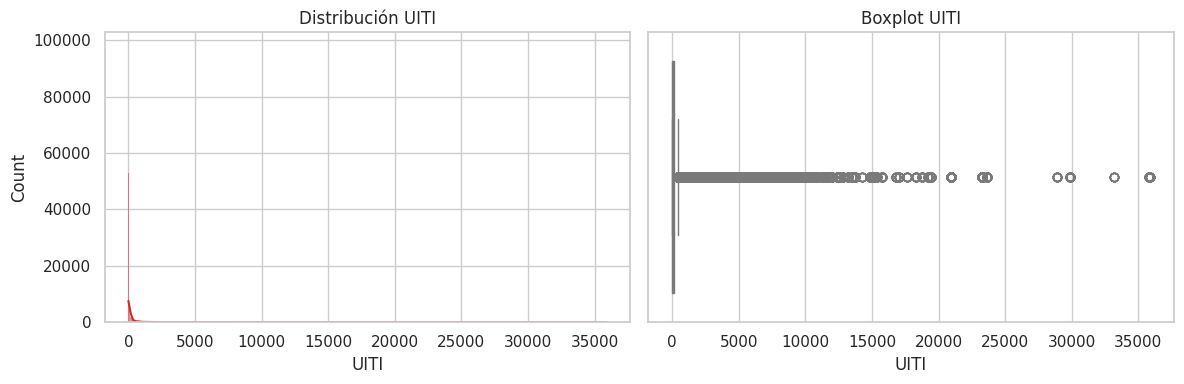

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET_COL], kde=True, ax=axes[0], color='#d62728')
axes[0].set_title('Distribución UITI')
sns.boxplot(x=df[TARGET_COL], ax=axes[1], color='#ff9896')
axes[1].set_title('Boxplot UITI')
plt.tight_layout()

display(df[TARGET_COL].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]))


lets see a Numerical correlations focused on UITI

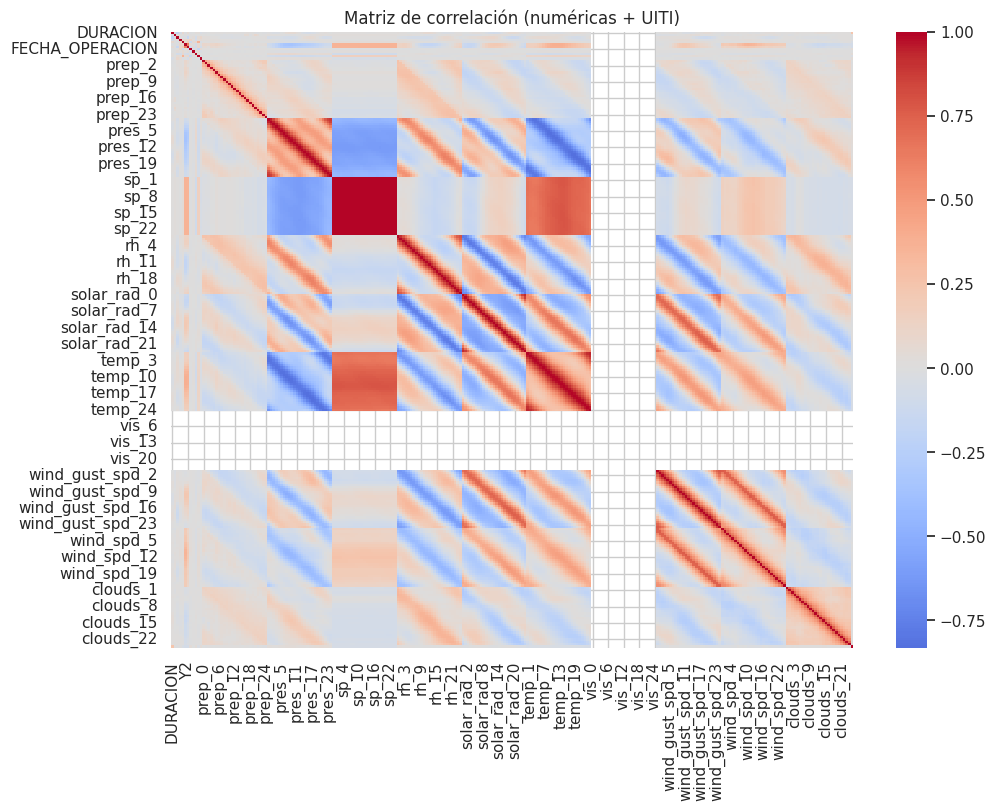

,corr_abs_uiti
DURACION,0.244427
X2,0.074738
Y2,0.073723
temp_23,0.056072
sp_2,0.054741
sp_1,0.054644
sp_3,0.054590
sp_14,0.054479
sp_15,0.054476
sp_13,0.054407


In [14]:
if numeric_features:
    corr_matrix = df[numeric_features + [TARGET_COL]].corr()
    plt.figure(figsize=(11, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
    plt.title('Matriz de correlación (numéricas + UITI)')
    plt.show()

    target_corr = (
        corr_matrix[TARGET_COL]
        .drop(TARGET_COL)
        .abs()
        .sort_values(ascending=False)
        .head(min(10, len(numeric_features)))
    )
    display(target_corr.to_frame('corr_abs_uiti'))
else:
    print('No se puede calcular correlación sin variables numéricas.')


from this, can we specified a bilateral relationships between UITI and the most correlated features

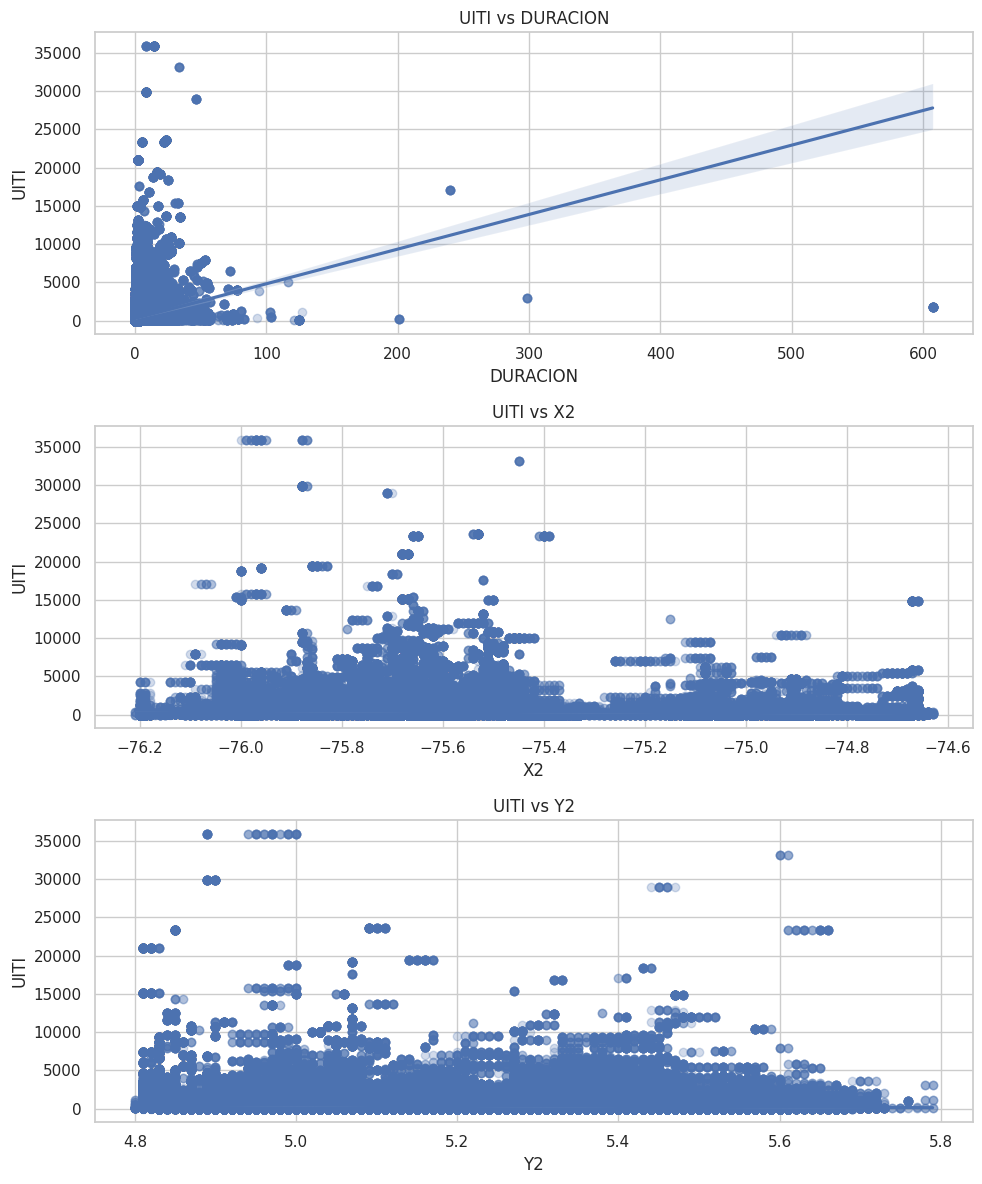

In [15]:

if numeric_features:
    corr_matrix = df[numeric_features + [TARGET_COL]].corr()
    main_drivers = (
        corr_matrix[TARGET_COL]
        .drop(TARGET_COL)
        .abs()
        .sort_values(ascending=False)
        .head(min(3, len(numeric_features)))
        .index
        .tolist()
    )

    fig, axes = plt.subplots(len(main_drivers), 1, figsize=(10, 4 * len(main_drivers)))
    if len(main_drivers) == 1:
        axes = [axes]
    for ax, col in zip(axes, main_drivers):
        sns.regplot(x=df[col], y=df[TARGET_COL], ax=ax, scatter_kws={'alpha': 0.25})
        ax.set_title(f'UITI vs {col}')
    plt.tight_layout()
else:
    print('Sin variables numéricas para scatter plots.')


In [16]:
display(df[numeric_features].describe())


,DURACION,COD_CAUSA,NFASES,NEUTRO,LONGITUD,X2,Y2,FECHA_OPERACION,LONG_CRUCETA,TRAFO,...,clouds_15,clouds_16,clouds_17,clouds_18,clouds_19,clouds_20,clouds_21,clouds_22,clouds_23,clouds_24
count,661811.000000,661811.000000,661811.000000,661811.000000,661811.000000,661811.000000,661811.000000,661811.000000,658852.000000,661811.000000,...,661811.000000,661811.000000,661811.000000,661811.000000,661811.000000,661811.000000,661811.000000,661811.000000,661811.000000,661811.000000
mean,2.063781,22.909710,2.679339,0.816683,167.817255,-75.491745,5.198221,1991.353111,1.511115,0.265277,...,90.542032,90.532167,90.485769,90.375178,90.351445,90.556919,90.522498,90.539418,90.368030,90.705881
std,7.001165,18.118408,0.602284,0.386926,192.379496,0.354947,0.226692,17.223574,9.309143,0.441481,...,20.360556,20.253703,20.098511,20.100155,19.969536,19.496389,19.548471,19.796550,20.025926,19.474028
min,0.001000,3.000000,1.000000,0.000000,0.400000,-76.210000,4.800000,1950.000000,-99.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.008000,20.000000,3.000000,1.000000,40.400000,-75.710000,5.020000,1980.000000,2.000000,0.000000,...,94.000000,94.000000,94.000000,94.000000,93.000000,93.000000,94.000000,94.000000,94.000000,93.000000
50%,0.030000,23.000000,3.000000,1.000000,96.400000,-75.600000,5.160000,1980.000000,2.500000,0.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
75%,1.320000,28.000000,3.000000,1.000000,223.600000,-75.340000,5.400000,2009.000000,3.000000,1.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
max,607.200000,564.000000,3.000000,1.000000,2807.400000,-74.630000,5.790000,2025.000000,9.000000,1.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


save the most correlationated 

In [17]:
top_cols = target_corr.index.tolist()          # nombres de columnas más correlacionadas


veamos tambien las distribuciones 

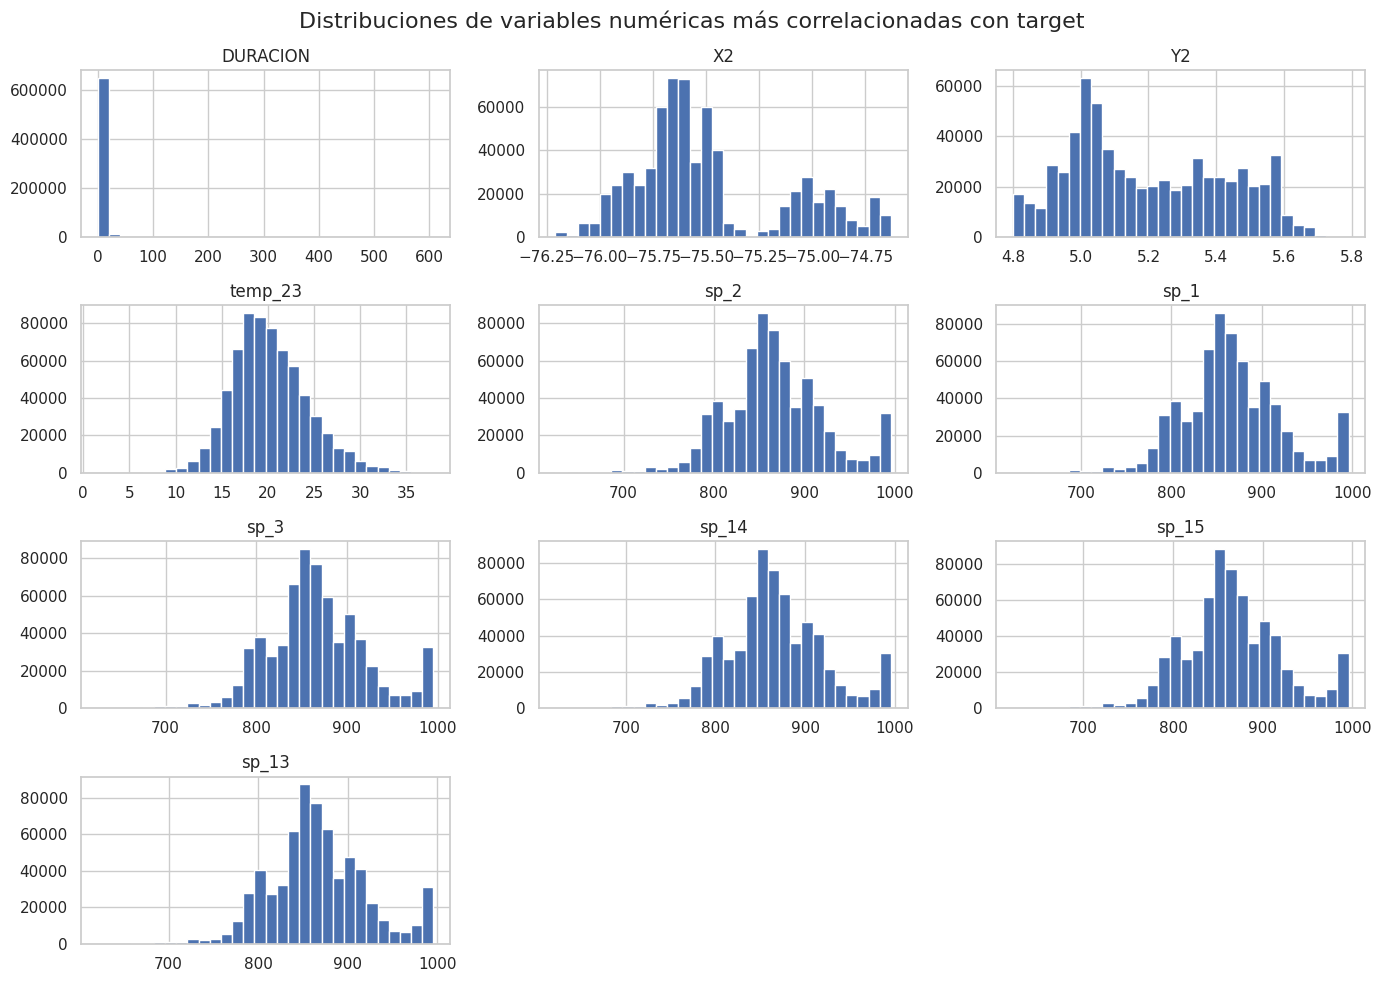

In [18]:
df[top_cols].hist(bins=30, figsize=(14, 10))
plt.suptitle('Distribuciones de variables numéricas más correlacionadas con target', fontsize=16)
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=300)
plt.show()

de igual forma, la matriz de correlacion para las numéricas

In [19]:
corr_matrix = df[top_cols].corr()


Y podemos visualizarla

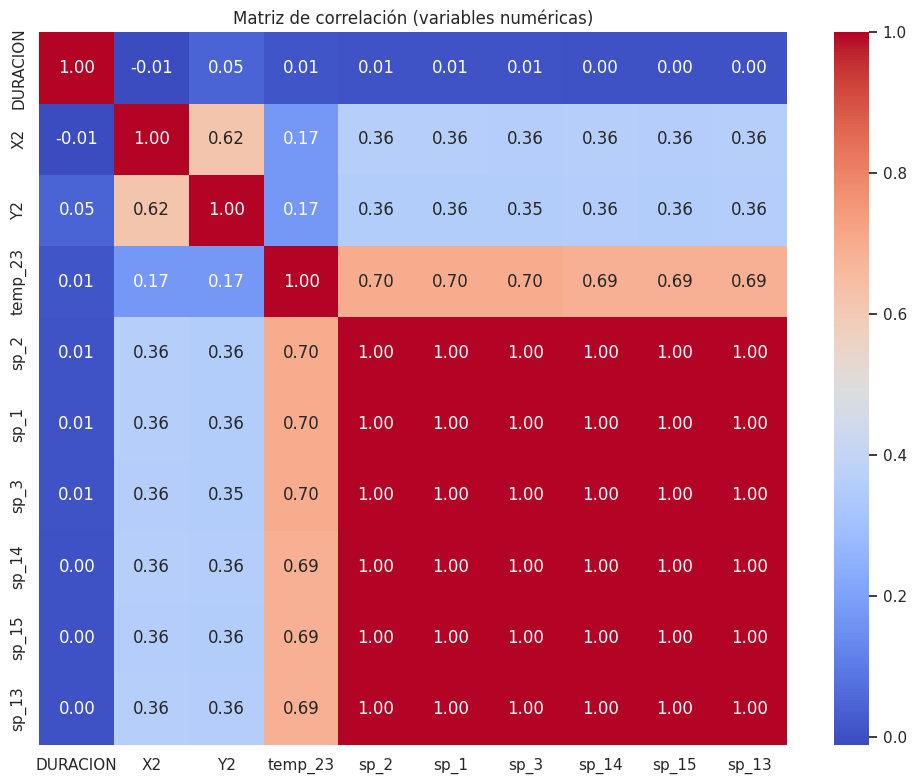

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300) # save figure 
plt.show()


tambien una tabla de frecuencia simples para nuestras categóricas

In [21]:
for col in categorical_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- CODIGO ---
CODIGO
14131       275
63870       275
13701       275
13702       275
14119       275
           ... 
L0278781      1
L0278780      1
L0278779      1
L0278778      1
L0278777      1
Name: count, Length: 40525, dtype: int64

--- TIPO ---
TIPO
3IG     185490
3RL     181646
3RG     145245
3CC      47941
2CC      29120
3CFR     24899
2CFR     15732
1CC      13591
3CR      10156
1CFR      4620
2RL       3007
3OS        124
2CR         97
3OC         75
1CR         68
Name: count, dtype: int64

--- FECHA ---
FECHA
14/05/2025 18:27    965
28/08/2025 11:13    500
25/01/2025 18:10    464
25/01/2025 21:35    440
17/06/2025 21:21    432
                   ... 
08/08/2025 15:41      1
13/01/2025 13:33      1
18/05/2025 7:53       1
05/05/2025 6:37       1
05/03/2025 21:18      1
Name: count, Length: 22149, dtype: int64

--- CALIBRE_F ---
CALIBRE_F
2        395739
2/0      118831
1/0       75194
4         50141
4/0       16408
3/0        3041
266,8      1009
336,4       712
6      

## preprocess

save our db 

before changes 

In [22]:
df_fe = df_original.copy()


vaemos los valroes nulos

In [23]:

missing_report = (
    df.isna()
    .sum()
    .to_frame(name='nulos')
    .assign(pct=lambda x: x['nulos'] / len(df))
    .sort_values(by='pct', ascending=False)
)
missing_report = missing_report[missing_report['nulos'] > 0]

if missing_report.empty:
    print('No se detectaron nulos.')
else:
    display(missing_report)
    px.bar(
        missing_report.reset_index().rename(columns={'index': 'columna'}),
        x='columna',
        y='pct',
        title='Porcentaje de valores faltantes',
    ).show()


,nulos,pct
vis_20,661811,1.000000
vis_21,661811,1.000000
vis_22,661811,1.000000
vis_23,661811,1.000000
vis_24,661811,1.000000
vis_4,661811,1.000000
vis_5,661811,1.000000
vis_6,661811,1.000000
vis_7,661811,1.000000
vis_8,661811,1.000000


manage MISSING values 

pipeline de preprocesamiento 

In [24]:
numeric_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('yeojohnson', PowerTransformer(method='yeo-johnson', standardize=False)),
        ('scaler', StandardScaler()),  # ask about standardize (standar scaling)
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]
)

Construcción del dataframe enriquecido con nuevas features


In [25]:
'''

feature_notes = []

parsed_datetime_cols = []
for col in datetime_features:
    parsed = pd.to_datetime(df_fe[col], errors='coerce', infer_datetime_format=True)
    coverage = parsed.notna().mean()
    if coverage < 0.5:
        continue
    df_fe[col] = parsed
    df_fe[f'{col}_year'] = parsed.dt.year
    df_fe[f'{col}_month'] = parsed.dt.month
    df_fe[f'{col}_day'] = parsed.dt.day
    df_fe[f'{col}_dow'] = parsed.dt.dayofweek
    parsed_datetime_cols.append(col)
    feature_notes.extend([f'{col}_year', f'{col}_month', f'{col}_day', f'{col}_dow'])

possible_duration_cols = [col for col in df_fe.columns if 'dur' in col.lower() or 'tiempo' in col.lower()]
for col in possible_duration_cols:
    df_fe[col] = pd.to_numeric(df_fe[col], errors='coerce')
    df_fe[f'{col}_log1p'] = np.log1p(df_fe[col].clip(lower=0))
    df_fe[f'{col}_zscore'] = (df_fe[col] - df_fe[col].mean()) / (df_fe[col].std() or 1)
    feature_notes.extend([f'{col}_log1p', f'{col}_zscore'])

cat_for_freq = sorted(set(categorical_features + [c for c in id_like_features if c in df.columns]))
for col in cat_for_freq:
    freq_series = df_fe[col].value_counts(dropna=False)
    df_fe[f'{col}_freq'] = df_fe[col].map(freq_series).fillna(0)
    feature_notes.append(f'{col}_freq')


def collapse_rare_categories(series: pd.Series, min_freq: float = 0.01) -> pd.Series:
    freq = series.value_counts(normalize=True, dropna=False)
    rare_labels = freq[freq < min_freq].index
    return series.replace(rare_labels, 'OTROS_NFL')

for col in categorical_features:
    df_fe[col] = collapse_rare_categories(df_fe[col].astype('string'))

numeric_features_enhanced = [col for col in df_fe.select_dtypes(include=[np.number]).columns if col != TARGET_COL]
categorical_features_clean = [col for col in df_fe.select_dtypes(exclude=[np.number]).columns if col != TARGET_COL]

print(f'Columnas originales: {df.shape[1]} -> tras ingeniería: {df_fe.shape[1]}')
print('Nuevas columnas clave:', feature_notes[:15], '...')
'''

transformers definition 

In [25]:
transformers = []
if numeric_features:
    transformers.append(('numeric', numeric_pipeline, numeric_features))
if categorical_features:
    transformers.append(('categorical', categorical_pipeline, categorical_features))


and define the preprocessor

In [26]:

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')


proceed saving data

In [29]:
import gc

In [27]:
df_processed = df_fe.copy()

define the feature cols

In [28]:
feature_cols = numeric_features + categorical_features

proceed with the data split]

In [30]:
X = df_processed[feature_cols]

use encode targe if its a classification task 

In [31]:
y = df_processed[TARGET_COL]
if y.dtype == 'O':
    y_le = LabelEncoder()
    y = y_le.fit_transform(y)


display info 

In [32]:
X.info()

In [33]:
y.info()

procedemos a codificar categóricas como indices (debido a que tabnet maneja embeddings)

proceed with the train split

60% train

In [34]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size= 0.6,  test_size=0.4, random_state=42)

In [35]:
X_train.info()

20% validacion 20% prueba

In [36]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp , test_size=0.5, random_state=42)

In [ ]:
print('Tamaños de los subconjuntos:')
print('Train :', X_train.shape)
print('Val   :', X_val.shape)
print('Test  :', X_test.shape)


## pre modeling

and apply the preprocessor 

In [ ]:
# preprocessor.fit(X_train)


In [ ]:
!pip install pytorch-tabnet

lets see a classification example

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

In [ ]:
clf = TabNetClassifier(
    n_d=16, n_a=16, n_steps=5, gamma=1.5,
    cat_idxs=cat_idxs, cat_dims=cat_dims, cat_emb_dim=3,
    lambda_sparse=1e-4, optimizer_params=dict(lr=1e-3),
    seed=42, verbose=10
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    eval_metric=['auc', 'accuracy'],
    max_epochs=200, patience=30,
    batch_size=1024, virtual_batch_size=128
)

preds = clf.predict(X_test)

probas = clf.predict_proba(X_test)
proba = probas[:, 1] if probas.shape[1] > 1 else None


proceed with feature importance 
import pandas as pd
feat_imp = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

 Local explain
explain_matrix, masks = clf.explain(X_valid[:200])


para regresión podriamos usar TabnetRegressior y métricas rmse/mae

## TABNET prediction

## RAG (retrieval-augmented-generation) implementation

### Basic RAG

cargamos y fragmentamos el paper, y un diccionario de metadata de circuitos (opcional)

In [ ]:
!pip install langchain langchain-community langchain-openai chromadb sentence-transformers pypdf


para modelos HFLocales

In [ ]:
!pip install transformers accelerate


In [ ]:

try:
    from langchain.chains import RetrievalQA  # versiones actuales
except ImportError:
    from langchain.chains.retrieval_qa.base import RetrievalQA  # fallback

In [ ]:
# Si faltan dependencias, en una celda previa:
# !pip install -q langchain-text-splitters langchain-community langchain-core langchain-openai chromadb sentence-transformers

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter  # <- cambio
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.chain import RetrievalQA
from langchain_openai import ChatOpenAI  # si usas OpenAI; ajusta a tu LLM

loader = PyPDFLoader("devContent/prjAdvances/docs/Paper_AI_CHECUNAL.pdf")
docs = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=120)
chunks = splitter.split_documents(docs)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = Chroma.from_documents(chunks, embedding=embeddings, persist_directory="devContent/prjAdvances/chroma_paper")
retriever = vectordb.as_retriever(search_kwargs={"k":4})
llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)  # o el modelo que uses
rag_chain = RetrievalQA.from_chain_type(llm=llm, retriever=retriever, chain_type="stuff")


Este RAG entrega contexto del paper para justificar hallazgos de variables relevantes.
]

### Agentic RAG

In [ ]:
### 

usamos la plantilla NPL6 LLM agentes como base : 